# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**


Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [ ]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Importar dataset
df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


La **prueba de hipótesis** es un procedimiento formal que nos permite validar afirmaciones sobre una población utilizando una muestra de datos. Se basa en el contraste de dos suposiciones:

1. **Hipótesis Nula ($H_0$):** Es la afirmación que se asume como verdadera por defecto (generalmente indica que "no hay efecto" o "no hay diferencia").

2. **Hipótesis Alternativa ($H_1$):** Es la afirmación que queremos probar (indica que "hay un efecto" o "existe una diferencia").

### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [ ]:
# Importar módulo
from scipy import stats

**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

In [ ]:
# Separaración de grupos
propinas_fumadores= df_tips[df_tips['smoker']=='Yes']['tip']
propinas_no_fumadores= df_tips[df_tips['smoker']=='No']['tip']

In [ ]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(propinas_fumadores, propinas_no_fumadores)

print(f"Estadístico T: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

Estadístico T: 0.0922
P-Value: 0.9266


In [ ]:
# Interpretar resultados


if p_value < 0.01:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia muy significativa entre las propinas de ambos grupos.")
elif p_value >= 0.01 and p_value < 0.05:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia altamente significativa entre las propinas de ambos grupos.")
elif p_value >= 0.05 and p_value < 0.10:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia moderadamente significativa entre las propinas de ambos grupos.")
else:
    print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
    print("No hay evidencia suficiente para decir que las propinas son diferentes.")


Conclusión: No podemos rechazar la Hipótesis Nula.
No hay evidencia suficiente para decir que las propinas son diferentes.


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

In [ ]:
# Definir regresión lineal
x = df_tips['total_bill']
y = df_tips['tip']
linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y = {beta} x + {alpha}')

y = 0.10502451738435338 x + 0.920269613554673


In [ ]:
# Predicción de valores con regresión lineal
tb_pred_lr = int(input('Agrega el valor del total de la cuenta que deseas predecir la propina: '))
y_pred_lr = round(beta * tb_pred_lr + alpha, 2)

print(f'La propina será de {y_pred_lr}')

Agrega el valor del total de la cuenta que deseas predecir la propina: 2
La propina será de 1.13


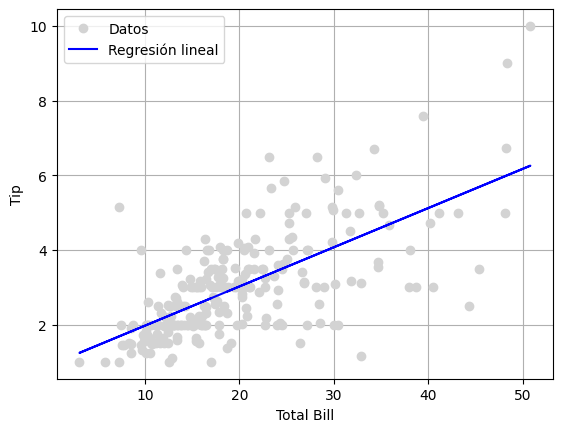

In [ ]:
# Visualizar regresión lineal
plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta*x + alpha, color = 'blue', label = 'Regresión lineal')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Iterar pérdida de la regresión lineal
num_iteraciones = 100
perdida_ml = []

for i in range(num_iteraciones):

    y_pred = np.polyval(linear_regression, x)
    error = ((y_pred - y ) ** 2).mean()
    perdida_ml.append(error)

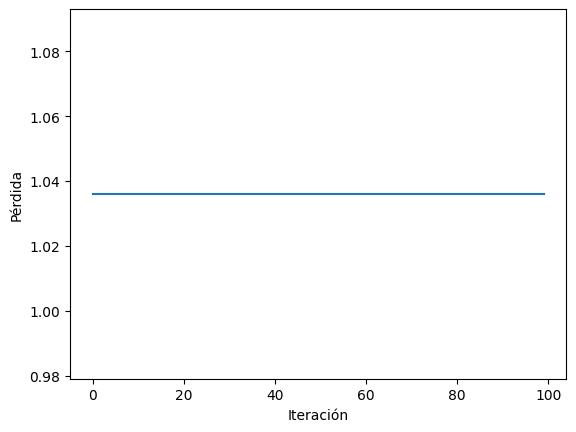

In [ ]:
# Visualizar pérdida de la regresión lineal
plt.plot(perdida_ml)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()

In [ ]:
perdida_ml[-1]

np.float64(1.036019442011377)

### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [ ]:
# Definir parámetros
tamaño_paso = 0.001
theta_0 = 0  # alfa de la ecuación de linea
theta_1 = 0  # beta de la ecuación de linea

perdida = []

x = df_tips['total_bill']
y = df_tips['tip']

n = len(x)

In [ ]:
# Realizar algoritmo del descenso de gradiente
num_iteraciones = 100

for i in range(num_iteraciones):
    y_pred = theta_1 * x + theta_0
    error = ((y_pred - y) ** 2).mean()
    perdida.append(error)

    d_theta_0 = (2 / n) * np.sum(y_pred - y)
    d_theta_1 = (2 / n) * np.sum((y_pred - y) * x)

    theta_0 = theta_0 - tamaño_paso * d_theta_0
    theta_1 = theta_1 - tamaño_paso * d_theta_1

print(f'y = {theta_1} x + {theta_0}')

y = 0.14222421840347957 x + 0.036159981060935556


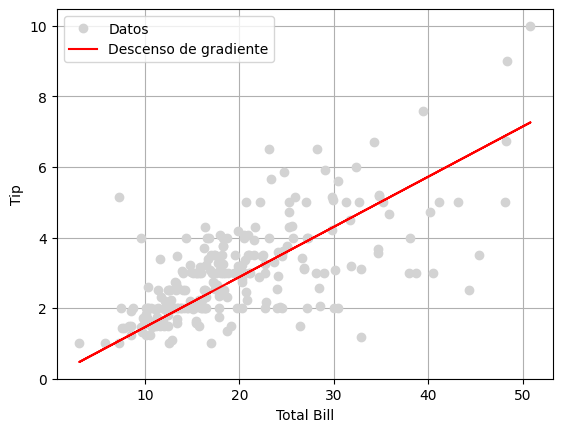

In [ ]:
# Visualizar la regresión lineal por descenso de gradiente
plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Descenso de gradiente')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

In [ ]:
perdida[-1]

np.float64(1.1672567371917777)

In [ ]:
# Predicción de valores con descenso de gradiente
tb_pred_gd = int(input('Agrega el valor del total de la cuenta que deseas predecir la propina: '))
y_pred_gd = round(theta_1 * tb_pred_gd + theta_0, 2)

print(f'La propina será de {y_pred_gd}')

Agrega el valor del total de la cuenta que deseas predecir la propina: 2
La propina será de 0.32


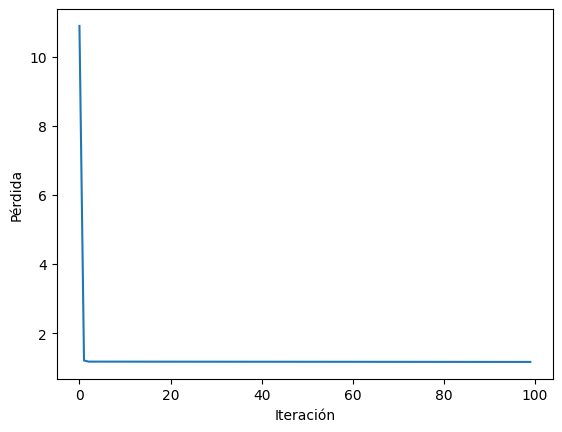

In [ ]:
# Visualizar las pérdidas
plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()

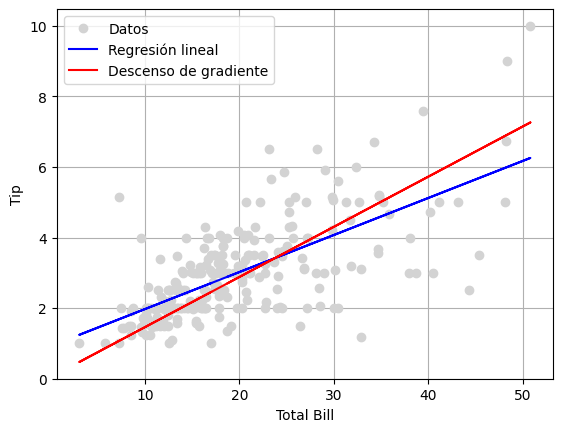

In [ ]:
# Comparar las rectas obtenidas por los algoritmos
plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta*x + alpha, color = 'blue', label = 'Regresión lineal')
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Descenso de gradiente')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid()
plt.show()

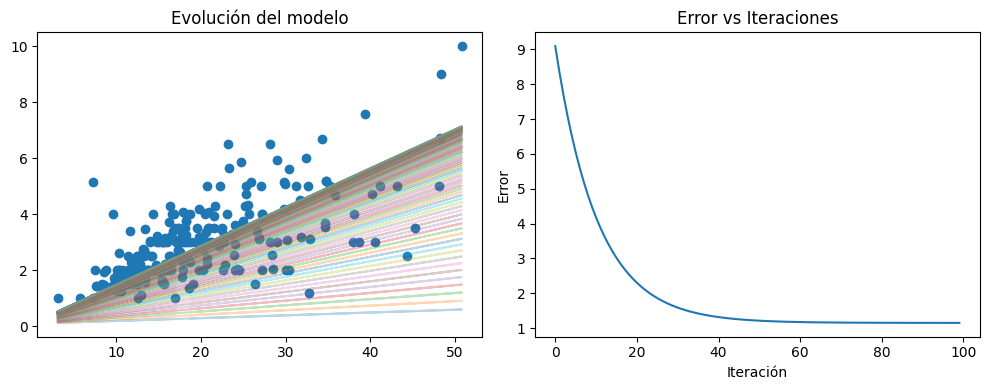

y = 0.1386 x + 0.0968  Error: 1.1503


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Datos (tú puedes cambiar estos)
x = df_tips['total_bill']
y = df_tips['tip']

# 🔹 Parámetros iniciales
m = 0.01
b = 0.09
lr = 0.00005
epochs = 100

# 🔹 Para guardar historia
errores = []
m_hist = []
b_hist = []

# 🔁 Entrenamiento
for _ in range(epochs):
    y_pred = m * x + b
    error = np.mean((y - y_pred)**2)

    errores.append(error)
    m_hist.append(m)
    b_hist.append(b)

    # Gradientes
    dm = (-2/len(x)) * np.sum(x * (y - y_pred))
    db = (-2/len(x)) * np.sum(y - y_pred)

    # Actualización
    m -= lr * dm
    b -= lr * db

# 📊 GRÁFICAS
plt.figure(figsize=(10,4))

# 🔹 Subplot 1: evolución de la recta
plt.subplot(1,2,1)
plt.scatter(x, y)

for i in range(len(m_hist)):
    plt.plot(x, m_hist[i]*x + b_hist[i], alpha=0.3)

plt.title("Evolución del modelo")

# 🔹 Subplot 2: error
plt.subplot(1,2,2)
plt.plot(errores)
plt.title("Error vs Iteraciones")
plt.xlabel("Iteración")
plt.ylabel("Error")

plt.tight_layout()
plt.show()

print(f'y = {m:.4f} x + {b:.4f}  Error: {errores[-1]:.4f}')

## **CHALLENGE: ANÁLISIS PREDICTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística inferencial***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística inferecial** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Prueba de hipótesis**
*   **Aprendizaje estadístico**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [29]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [30]:
# Importar dataset
df_taxis = sns.load_dataset('taxis')
print(df_taxis.head())
print(df_taxis.info())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

**3. Realiza una prueba de hipótesis:** Determina si existe una diferencia significativa entre la distancia recorrida de los taxis color amarillo y verde.

Donde:

   * H0: La media de distancia es igual para ambos colores.
   * H1: La media de distancia es distinta entre colores.

In [31]:
# Importar módulo
from scipy import stats

In [32]:
# Separación de grupos
distancias_taxis_amarillos = df_taxis[df_taxis['color']=='yellow']['distance']
distancias_taxis_verdes = df_taxis[df_taxis['color']=='green']['distance']

In [33]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(distancias_taxis_amarillos, distancias_taxis_verdes)

print(f"Estadístico T: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

Estadístico T: -3.4060
P-Value: 0.0007


In [34]:
# Interpretación automática
if p_value < 0.01:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia muy significativa entre las distancias de ambos colores de taxi.")
elif p_value >= 0.01 and p_value < 0.05:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia altamente significativa entre las distancias de ambos colores de taxi.")
elif p_value >= 0.05 and p_value < 0.10:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia moderadamente significativa entre las distancias de ambos colores de taxi.")
else:
    print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
    print("No hay evidencia suficiente para decir que las distancias son diferentes.")


Conclusión: Rechazamos la Hipótesis Nula.
Existe una diferencia muy significativa entre las distancias de ambos colores de taxi.


**4. Realiza un aprendizaje estadístico:**

   * Crea un modelo de regresión lineal simple para predecir el costo del viaje en función de la distancia recorrida.
   * Ajusta el modelo a través del algoritmo de optimización del descenso de gradiente.
   * Utiliza el modelo ajustado para realizar una predicción de cuánto costará un viaje de dado un valor agregado por el usuario en unidades de distancia.

In [41]:
# Definir regresión lineal
x = df_taxis['distance']
y = df_taxis['total']

linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y = {beta} x + {alpha}')

y = 3.2651658040714597 x + 8.641918776697052


In [36]:
# Definir parámetros
tamaño_paso = 0.001
theta_0 = 0  # alfa de la ecuación de linea
theta_1 = 0  # beta de la ecuación de linea

perdida = []

n = len(x)

# Realizar algoritmo del descenso de gradiente
num_iteraciones = 100

for i in range(num_iteraciones):
    y_pred = theta_1 * x + theta_0
    error = ((y_pred - y) ** 2).mean()
    perdida.append(error)

    d_theta_0 = (2 / n) * np.sum(y_pred - y)
    d_theta_1 = (2 / n) * np.sum((y_pred - y) * x)

    theta_0 = theta_0 - tamaño_paso * d_theta_0
    theta_1 = theta_1 - tamaño_paso * d_theta_1

print(f'y = {theta_1} x + {theta_0}')

y = 4.168174314857403 x + 1.4812777584944634


In [40]:
# Predicción de valores con descenso de gradiente
tb_pred_gd = float(input('Ingresa la distancia recorrida en millas para predecir el costo en dólares: '))
y_pred_gd = round(theta_1 * tb_pred_gd + theta_0, 2)

print(f'El costo será de {y_pred_gd} dólares')

Ingresa la distancia recorrida en millas para predecir el costo en dólares: 2.16
El costo será de 10.48 dólares


**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

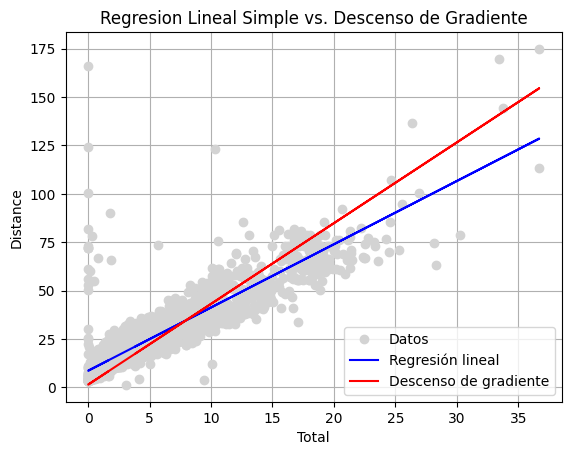

In [38]:
# Visualizar regresiones
plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta*x + alpha, color = 'blue', label = 'Regresión lineal')
plt.title("Regresion Lineal Simple vs. Descenso de Gradiente")
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Descenso de gradiente')
plt.xlabel('Total')
plt.ylabel('Distance')
plt.legend()
plt.grid()
plt.show()

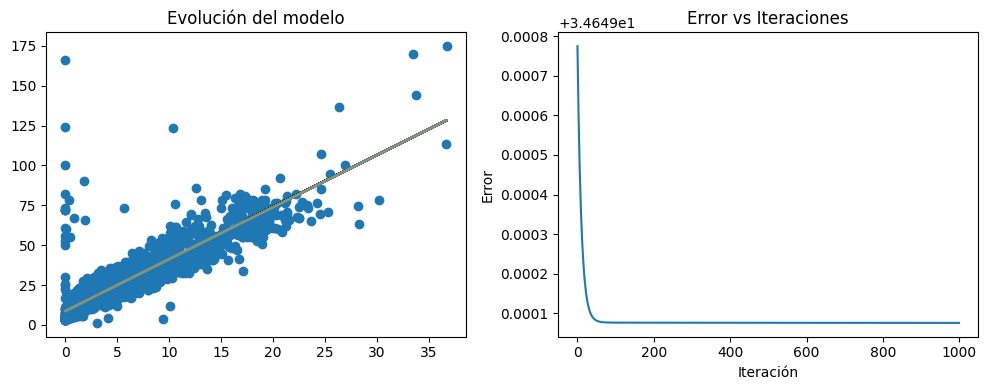

y = 3.2652 x + 8.6416  Error: 34.6491


In [45]:
# Visualizar función de costo

# 🔹 Parámetros iniciales
m = 3.26 # pendiente
b = 8.64 # intercepto
lr = 0.001 # learning rate/ tasa de aprendizaje
epochs = 1000 # Número de iteraciones

# 🔹 Para guardar historia
errores = []
m_hist = []
b_hist = []

# 🔁 Entrenamiento
for _ in range(epochs):
    y_pred = m * x + b
    error = np.mean((y - y_pred)**2)

    errores.append(error)
    m_hist.append(m)
    b_hist.append(b)

    # Gradientes
    dm = (-2/len(x)) * np.sum(x * (y - y_pred))
    db = (-2/len(x)) * np.sum(y - y_pred)

    # Actualización
    m -= lr * dm
    b -= lr * db

# 📊 GRÁFICAS
plt.figure(figsize=(10,4))

# 🔹 Subplot 1: evolución de la recta
plt.subplot(1,2,1)
plt.scatter(x, y)

for i in range(len(m_hist)):
    plt.plot(x, m_hist[i]*x + b_hist[i], alpha=0.3)

plt.title("Evolución del modelo")

# 🔹 Subplot 2: error
plt.subplot(1,2,2)
plt.plot(errores)
plt.title("Error vs Iteraciones")
plt.xlabel("Iteración")
plt.ylabel("Error")

plt.tight_layout()
plt.show()

print(f'y = {m:.4f} x + {b:.4f}  Error: {errores[-1]:.4f}')